# Chapter 6: Theoretical limits of perceptrons and the XOR-problem
For the implemented class, see `py_perceptron.py` in the `py_perceptron` folder.

In [1]:
import sys
import os

# Ensure import from parent directory works
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../')))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import pickle
from sklearn.model_selection import train_test_split
from py_perceptron import PyPerceptron

In [3]:
def heaviside_step(x):
    # Heaviside step function
    return 1 if x >= 0 else 0

In [4]:
REASON_MAP = { 
        "Fitting": 0, 
        "Holes": 1, 
        "Zipper": 3, 
        "Smell": 4, 
        "Missing pieces": 5, 
        "Wrong style": 6, 
        "Price difference": 7, 
        "Early delivery": 8, 
        "Not ordered": 9, 
        "Stains": 10, 
        "Late delivery": 11, 
        "Color / Print": 12, 
        "Double delivery": 13,
        "Sew fault": 14, 
        "Wrong assortment": 15, 
        "Fabric / Woven fault ": 16, 
        "Size / Length": 17, 
        "Others": 18, 
        "Buttons": 19 ,
        "NO REASON": 20,
    }

In [5]:
csv_data = pd.read_csv('../../data/prod_claims_2024-09-15_2024-09-21.csv')
print(csv_data.shape)
# Change labels: If 0, keep as 0, if 1 or above, change to 1 (binary classification)
csv_data['label'] = csv_data['handling.name'].apply(lambda x: 0 if x == 'Rejected' else 1)

# Map reason string to number
csv_data['reason'] = csv_data['reason.name'].map(REASON_MAP)
csv_data['reason'] = csv_data['reason'].fillna(20)  # Fill NaN with 20 (NO REASON)

# Remove all where quantity is 0
csv_data = csv_data[csv_data['quantity'] != 0]

# Remove top and bottom 1% of wholesale price and quantity
csv_data = csv_data[csv_data['wholesale_price'].between(csv_data['wholesale_price'].quantile(0.01), csv_data['wholesale_price'].quantile(0.99))]
csv_data = csv_data[csv_data['quantity'].between(csv_data['quantity'].quantile(0.1), csv_data['quantity'].quantile(0.9))]


# Print the number of accepted and rejected claims
csv_data_accepted = csv_data[csv_data['label'] == 1]
csv_data_rejected = csv_data[csv_data['label'] == 0]
print(f"Accepted claims: {len(csv_data_accepted)}")
print(f"Rejected claims: {len(csv_data_rejected)}")


# Split data into features and labels
X = csv_data.drop(columns=['handling.name', 'label'])
y = csv_data['label']

# Identify 3 features to use (for simplicity)
X = X[['number', 'reason', 'quantity', 'has_attachment']] # wholesale_price
X = X[['reason', 'quantity', 'has_attachment']]

X_all = np.array(X)
y_all = np.array(y)

(2868, 17)
Accepted claims: 2487
Rejected claims: 80


Confusion Matrix:
[[  49    3]
 [2438   77]]


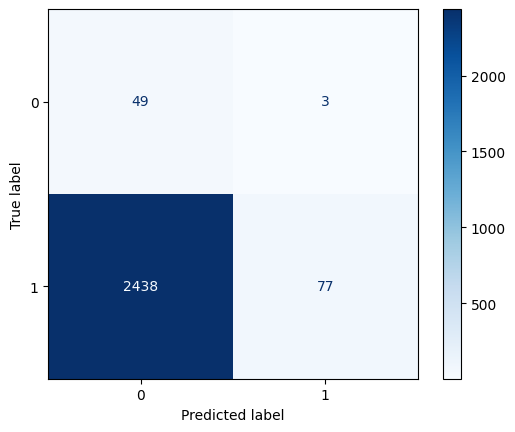

Final weights: [ 0.04 -0.14  0.04  0.05]
Plane formula: 0 = 0.040000000000000015 + -0.14 * x1 + 0.040000000000000015 * x2 + 0.05000000000000002 * x3
Decision Boundary: x3 = [[-1.6        -1.03434343 -0.46868687 ... 53.26868687 53.83434343
  54.4       ]
 [-1.68080808 -1.11515152 -0.54949495 ... 53.18787879 53.75353535
  54.31919192]
 [-1.76161616 -1.1959596  -0.63030303 ... 53.10707071 53.67272727
  54.23838384]
 ...
 [-9.43838384 -8.87272727 -8.30707071 ... 45.43030303 45.9959596
  46.56161616]
 [-9.51919192 -8.95353535 -8.38787879 ... 45.34949495 45.91515152
  46.48080808]
 [-9.6        -9.03434343 -8.46868687 ... 45.26868687 45.83434343
  46.4       ]]
Decision Boundary: 0 = 0.040000000000000015 + -0.14 * x1 + 0.040000000000000015 * x2 + 0.05000000000000002 * x3


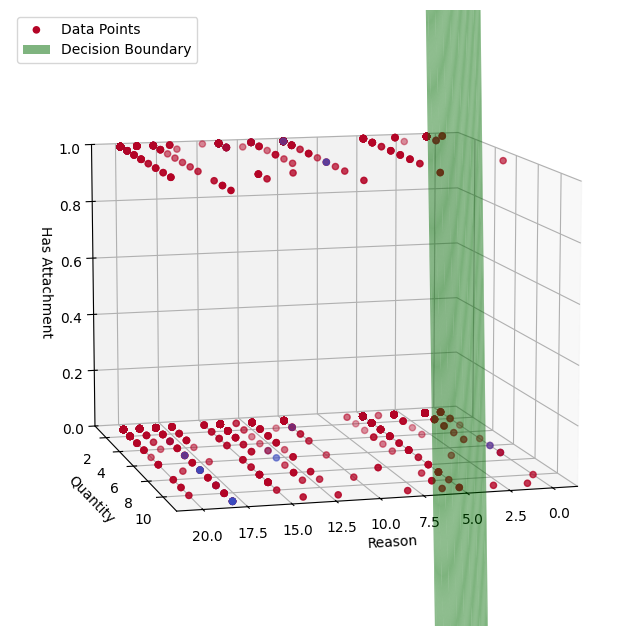

In [6]:
# Use trained model to make predictions
perceptron = pickle.load(open('../../models/perceptron_model.pkl', 'rb'))


y_pred = perceptron.predict(X_all)

## Evaluate the model
# Metrics
perceptron.score(y_all, y_pred)

# Calculate confusion matrix
confusion_matrix = perceptron.confusion_matrix(y_all, y_pred)
print(f"Confusion Matrix:\n{confusion_matrix}")
perceptron.plot_confusion_matrix(y_all, y_pred)

# # Plot the decision boundary
def plot_decision_boundary_3d(weights, X, y):
    # Extract weights
    w0, w1, w2, w3 = weights

    # Create a meshgrid for 3D plotting
    # Get ranges for x1 and x2
    x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
    x2_min, x2_max = X[:, 1].min(), X[:, 1].max()
    # Create a grid of points
    x1_range = np.linspace(x1_min, x1_max, 100)
    x2_range = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_range, x2_range)

    # Calculate the decision boundary
    Z = -(w0 + w1 * X1 + w2 * X2) / w3

    # Formula:
    print(f"Decision Boundary: x3 = {-(w0 + w1 * X1 + w2 * X2) / w3}")
    print(f"Decision Boundary: 0 = {w0} + {w1} * x1 + {w2} * x2 + {w3} * x3")

    # Plot data points
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='coolwarm', marker='o', label='Data Points')
    ax.plot_surface(X1, X2, Z, alpha=0.5, color='green', label='Decision Boundary')
    ax.set_xlabel('Reason')
    ax.set_ylabel('Quantity')
    ax.set_zlabel('Has Attachment')
    ax.set_zlim(0, 1)  # Set z-axis limits
    ax.set_axis_on()
    ax.legend()
    ax.view_init(elev=10, azim=75)  # Adjust the view angle
    ax.grid(True)
    plt.show()

print(f"Final weights: {perceptron.get_weights()}")
print(f"Plane formula: 0 = {perceptron.get_weights()[0]} + {perceptron.get_weights()[1]} * x1 + {perceptron.get_weights()[2]} * x2 + {perceptron.get_weights()[3]} * x3")
plot_decision_boundary_3d(perceptron.get_weights(), X_all, y_all)

### XOR-problem

   x1  x2  y
0   0   0  0
1   0   1  1
2   1   0  1
3   1   1  0


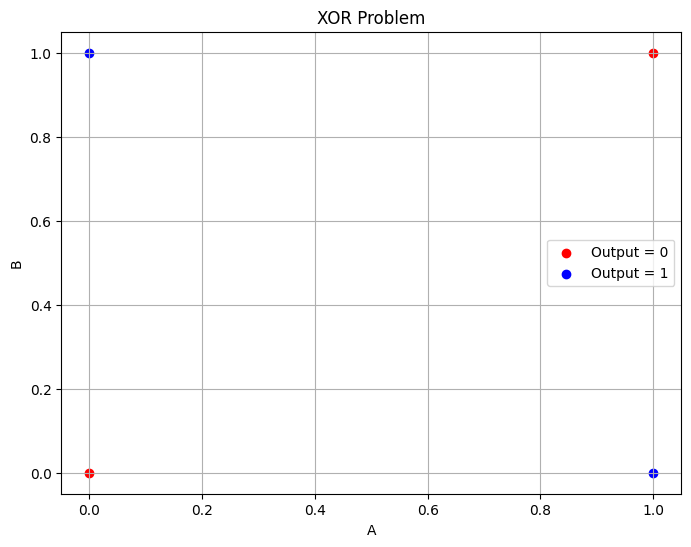

In [7]:
### XOR-problem explainer
data = pd.DataFrame({
    'x1': [0, 0, 1, 1],
    'x2': [0, 1, 0, 1],
    'y': [0, 1, 1, 0]
})
print(data)

# Plot the XOR data
plt.figure(figsize=(8, 6))
plt.scatter(data[data['y'] == 0]['x1'], data[data['y'] == 0]['x2'], color='red', label='Output = 0')
plt.scatter(data[data['y'] == 1]['x1'], data[data['y'] == 1]['x2'], color='blue', label='Output = 1')
plt.title('XOR Problem')
plt.xlabel('A')
plt.ylabel('B')
plt.legend()
plt.grid()
plt.show()